# 🔵 Model B — SLA Adherence Likelihood (5G Dataset)
**Groupe : Azerty67 | ESPRIT — Smart Slice Selection in 5G/6G**

---

## Objectif du DSO
Estimer la **probabilité qu'une assignation de slice satisfera les contraintes QoS** (latence, perte de paquets) sous les conditions réseau actuelles.

> *The SLA adherence model is formulated as a probabilistic binary classification problem, where the model predicts the likelihood that a given slice configuration satisfies SLA constraints. This probability output directly serves as a confidence score, enabling risk-aware decision-making in slice selection.*

| Output | Interprétation |
|--------|----------------|
| `P(sla_met=1) = 0.9` | SLA très probable ✅ — maintenir la session |
| `P(sla_met=1) = 0.3` | Risque élevé ❌ — déclencher une action corrective |

---

## Structure du Notebook
```
1.  Setup & Imports
2.  Chargement du Dataset
3.  Feature Selection — Critère 1 : Logique DSO/BO
4.  Feature Selection — Critère 2 : Matrice de Corrélation
5.  Feature Selection — Critère 3 : Emplacement du Modèle (Near-RT RIC)
6.  Résumé Final du Feature Selection
7.  Preprocessing (SMOTE + Scaling)
8.  Modélisation (Baseline → RF → XGBoost)
9.  Évaluation & Comparaison
10. Explainability (SHAP)
11. MLOps — Sauvegarde & Déploiement
```

---
## 1. Setup & Imports

In [6]:
# ============================================================
# Installation des dépendances (Colab / environnement vierge)
# ============================================================
# Décommenter si nécessaire :
# !pip install xgboost shap imbalanced-learn scikit-learn pandas matplotlib seaborn -q

import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, f1_score, precision_score, recall_score
)

# Imbalanced data
from imblearn.over_sampling import SMOTE

# XGBoost
from xgboost import XGBClassifier

# Explainability
import shap

# MLOps
import joblib
import json
import os
from datetime import datetime

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style global
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('✅ Tous les imports effectués avec succès.')
print(f'🕐 Timestamp : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ Tous les imports effectués avec succès.
🕐 Timestamp : 2026-03-29 13:55:48


---
## 2. Chargement du Dataset

In [7]:
# ============================================================
# Chargement du dataset 5G préparé par le pipeline principal
# ============================================================
df = pd.read_csv('5G_prepared.csv')

print('=' * 55)
print(f'✅  5G dataset chargé')
print(f'   Shape              : {df.shape}')
print(f'   Colonnes           : {list(df.columns)}')
print(f'   Valeurs manquantes : {df.isnull().sum().sum()}')
print('=' * 55)

# Distribution de la cible
print('\n📊 Distribution de sla_met (target) :')
vc  = df['sla_met'].value_counts()
vcp = df['sla_met'].value_counts(normalize=True).round(3)
print(f'   sla_met = 0 (SLA NON respecté) : {vc[0]} ({vcp[0]*100:.1f}%)')
print(f'   sla_met = 1 (SLA respecté)     : {vc[1]} ({vcp[1]*100:.1f}%)')
print(f'\n⚠️  Déséquilibre détecté → SMOTE sera appliqué lors du preprocessing.')

# Distribution par slice type
print('\n📡 Distribution par slice Type :')
slice_map = {1: 'eMBB', 2: 'mMTC', 3: 'URLLC'}
df['slice_name'] = df['slice Type'].map(slice_map)
print(df.groupby('slice_name')['sla_met'].value_counts().unstack(fill_value=0))
df.drop(columns=['slice_name'], inplace=True)

df.head(5)

✅  5G dataset chargé
   Shape              : (31583, 22)
   Colonnes           : ['LTE/5g Category', 'Time', 'Packet Loss Rate', 'Packet delay', 'IoT', 'LTE/5G', 'GBR', 'Non-GBR', 'AR/VR/Gaming', 'Healthcare', 'Industry 4.0', 'IoT Devices', 'Public Safety', 'Smart City & Home', 'Smart Transportation', 'Smartphone', 'slice Type', 'service_intensity', 'delay_risk', 'loss_risk', 'risk_score', 'sla_met']
   Valeurs manquantes : 0

📊 Distribution de sla_met (target) :
   sla_met = 0 (SLA NON respecté) : 24191 (76.6%)
   sla_met = 1 (SLA respecté)     : 7392 (23.4%)

⚠️  Déséquilibre détecté → SMOTE sera appliqué lors du preprocessing.

📡 Distribution par slice Type :
sla_met         0     1
slice_name             
URLLC        7392     0
eMBB        16799     0
mMTC            0  7392


,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,...,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type,service_intensity,delay_risk,loss_risk,risk_score,sla_met
0,14,0,0.000001,10,1,0,0,1,0,0,...,1,0,0,0,3,2,0.033333,0.0001,0.016717,0
1,18,20,0.001000,100,0,1,1,0,1,0,...,0,0,0,0,1,1,0.333333,0.1000,0.216667,0
2,17,14,0.000001,300,0,1,0,1,0,0,...,0,0,0,1,1,1,1.000000,0.0001,0.500050,0
3,3,17,0.010000,100,0,1,0,1,0,0,...,0,0,0,1,1,1,0.333333,1.0000,0.666667,0
4,9,4,0.010000,50,1,0,0,1,0,0,...,0,1,0,0,2,2,0.166667,1.0000,0.583333,1


---
## 3. Feature Selection — Critère 1 : Logique DSO / Business Objectives

### Raisonnement
Le **Model B — SLA Adherence** prédit `P(sla_met = 1 | features)`, c'est-à-dire le score de confiance qu'une session respectera son SLA. Les features doivent donc capturer :

1. **Ce qui définit le SLA** → les métriques QoS mesurées (delay, loss)
2. **Ce qui conditionne le SLA** → le type de slice et son contrat (GBR/Non-GBR)
3. **Le contexte du service** → quel type d'usage justifie quel niveau de SLA

Les SLA sont définis par slice type avec les seuils suivants :

| Slice  | Delay max | Packet Loss max |
|--------|-----------|------------------|
| URLLC  | 1 ms      | 0.00001          |
| eMBB   | 10 ms     | 0.01             |
| mMTC   | 1000 ms   | 0.01             |

In [8]:
# ============================================================
# CRITÈRE 1 — Analyse logique DSO / Business Objectives
# ============================================================

feature_logic = {
    # ── Core QoS (OBLIGATOIRE) ──────────────────────────────
    'Packet Loss Rate'    : ('✅ KEEP', 'Core QoS',       'Métrique directe du SLA — loss_max varie par slice type'),
    'Packet delay'        : ('✅ KEEP', 'Core QoS',       'Métrique directe du SLA — delay_max varie par slice type'),
    # ── Contexte réseau ─────────────────────────────────────
    'slice Type'          : ('✅ KEEP', 'Contexte réseau','Définit les seuils SLA (URLLC/eMBB/mMTC) — indispensable'),
    'service_intensity'   : ('✅ KEEP', 'Contexte réseau','Agrège le nb de services actifs → encode la charge applicative'),
    'LTE/5G'              : ('✅ KEEP', 'Contexte réseau','Indique le type réseau UE → impacte le profil QoS atteignable'),
    # ── Use-cases (les plus corrélés retenus) ───────────────
    'Smart City & Home'   : ('✅ KEEP', 'Use-case',       'Corrélation 0.66 avec sla_met — service mMTC best-effort'),
    'IoT Devices'         : ('✅ KEEP', 'Use-case',       'Corrélation 0.45 avec sla_met — profile trafic IoT faible latence'),
    'Public Safety'       : ('✅ KEEP', 'Use-case',       'Service mission-critique — corrélation significative négative (URLLC-like)'),
    # ── Features éliminées ──────────────────────────────────
    'delay_risk'          : ('❌ DROP', 'Data leakage',   'Dérivé de Packet delay (corrélation = 1.0) → fuite d\'information'),
    'loss_risk'           : ('❌ DROP', 'Data leakage',   'Dérivé de Packet Loss Rate (corrélation = 1.0) → fuite d\'information'),
    'risk_score'          : ('❌ DROP', 'Data leakage',   'Dérivé de delay_risk + loss_risk → multicolinéaire'),
    'Time'                : ('❌ DROP', 'Bruit',          'Corrélation 0.004 avec sla_met → aucun signal utile'),
    'LTE/5g Category'     : ('❌ DROP', 'Bruit',          'Corrélation 0.056 avec sla_met → signal négligeable'),
    'GBR'                 : ('❌ DROP', 'Redondance',     'Redondant avec slice Type — le SLA contractuel est déjà encodé par slice Type'),
    'Non-GBR'             : ('❌ DROP', 'Redondance',     'Anti-corrélé parfait avec GBR (GBR + Non-GBR = 1 toujours)'),
    'IoT'                 : ('❌ DROP', 'Redondance',     'Capturé par service_intensity et LTE/5G — information dupliquée'),
    'Smartphone'          : ('❌ DROP', 'Faible signal',  'Corrélation -0.48 mais redondant avec LTE/5G'),
    'Industry 4.0'        : ('❌ DROP', 'Faible signal',  'Moins corrélé que les 3 use-cases retenus'),
    'AR/VR/Gaming'        : ('❌ DROP', 'Faible signal',  'Corrélation -0.19 — signal insuffisant vs use-cases retenus'),
    'Healthcare'          : ('❌ DROP', 'Faible signal',  'Corrélation -0.14 — signal insuffisant vs use-cases retenus'),
    'Smart Transportation': ('❌ DROP', 'Faible signal',  'Corrélation -0.14 — signal insuffisant vs use-cases retenus'),
}

print('=' * 85)
print(f'{"Feature":<25} {"Décision":<12} {"Groupe":<18} {"Justification"}')
print('=' * 85)
for feat, (decision, groupe, reason) in feature_logic.items():
    print(f'{feat:<25} {decision:<12} {groupe:<18} {reason}')
print('=' * 85)

FEATURES_KEEP = [k for k, (d, _, _) in feature_logic.items() if d == '✅ KEEP']
FEATURES_DROP = [k for k, (d, _, _) in feature_logic.items() if d == '❌ DROP']
print(f'\n✅ Features sélectionnées ({len(FEATURES_KEEP)}) : {FEATURES_KEEP}')
print(f'❌ Features éliminées   ({len(FEATURES_DROP)}) : {FEATURES_DROP}')

Feature                   Décision     Groupe             Justification
Packet Loss Rate          ✅ KEEP       Core QoS           Métrique directe du SLA — loss_max varie par slice type
Packet delay              ✅ KEEP       Core QoS           Métrique directe du SLA — delay_max varie par slice type
slice Type                ✅ KEEP       Contexte réseau    Définit les seuils SLA (URLLC/eMBB/mMTC) — indispensable
service_intensity         ✅ KEEP       Contexte réseau    Agrège le nb de services actifs → encode la charge applicative
LTE/5G                    ✅ KEEP       Contexte réseau    Indique le type réseau UE → impacte le profil QoS atteignable
Smart City & Home         ✅ KEEP       Use-case           Corrélation 0.66 avec sla_met — service mMTC best-effort
IoT Devices               ✅ KEEP       Use-case           Corrélation 0.45 avec sla_met — profile trafic IoT faible latence
Public Safety             ✅ KEEP       Use-case           Service mission-critique — corrélation signifi

---
## 4. Feature Selection — Critère 2 : Matrice de Corrélation

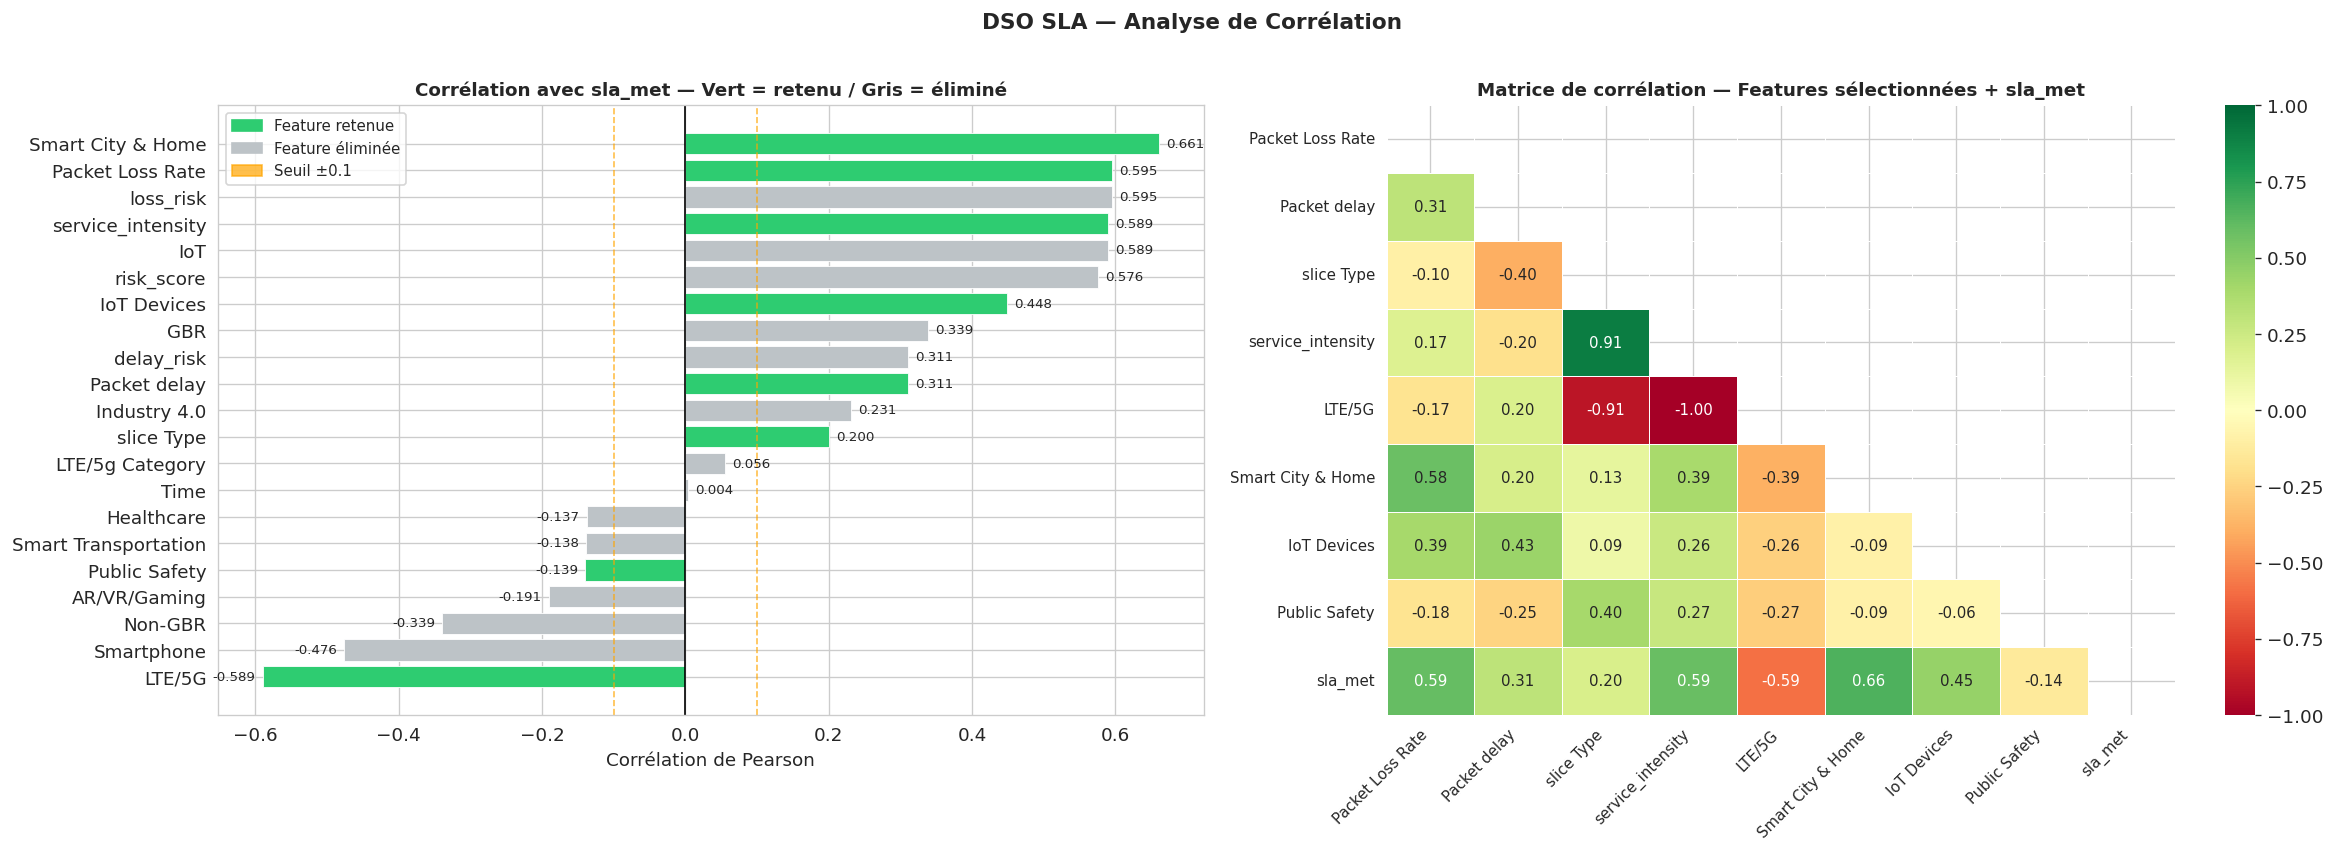


📊 Corrélations avec sla_met (features retenues) :
  Smart City & Home         : +0.6608  🔴 FORT
  Packet Loss Rate          : +0.5947  🔴 FORT
  service_intensity         : +0.5893  🔴 FORT
  IoT Devices               : +0.4484  🔴 FORT
  Packet delay              : +0.3112  🔴 FORT
  slice Type                : +0.2001  🟡 MODÉRÉ
  Public Safety             : -0.1393  🟡 MODÉRÉ
  LTE/5G                    : -0.5893  🔴 FORT


In [9]:
# ============================================================
# CRITÈRE 2 — Matrice de corrélation
# ============================================================

all_numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_matrix = df[all_numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Plot 1 : Corrélation avec sla_met (barplot — toutes features) ---
corr_target = corr_matrix['sla_met'].drop('sla_met').sort_values()
colors_bar  = []
for feat, val in corr_target.items():
    if feat in FEATURES_KEEP:
        colors_bar.append('#2ecc71')   # vert = retenu
    else:
        colors_bar.append('#bdc3c7')   # gris = éliminé

axes[0].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white', linewidth=0.5)
axes[0].axvline(0,    color='black',  linewidth=1)
axes[0].axvline(0.1,  color='orange', linewidth=1, linestyle='--', alpha=0.7)
axes[0].axvline(-0.1, color='orange', linewidth=1, linestyle='--', alpha=0.7)
axes[0].set_title('Corrélation avec sla_met — Vert = retenu / Gris = éliminé',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Corrélation de Pearson')

# Légende
import matplotlib.patches as mpatches
axes[0].legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Feature retenue'),
    mpatches.Patch(color='#bdc3c7', label='Feature éliminée'),
    mpatches.Patch(color='orange',  label='Seuil ±0.1', alpha=0.7),
], fontsize=9)

for i, (v, name) in enumerate(zip(corr_target.values, corr_target.index)):
    axes[0].text(v + (0.01 if v >= 0 else -0.01), i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=8)

# --- Plot 2 : Heatmap features sélectionnées ---
selected_for_heatmap = FEATURES_KEEP + ['sla_met']
corr_selected = df[selected_for_heatmap].corr()

mask = np.zeros_like(corr_selected, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_selected, mask=mask, ax=axes[1],
            annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
axes[1].set_title('Matrice de corrélation — Features sélectionnées + sla_met',
                  fontweight='bold', fontsize=11)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(axes[1].get_yticklabels(), fontsize=9)

plt.suptitle('DSO SLA — Analyse de Corrélation', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('correlation_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📊 Corrélations avec sla_met (features retenues) :')
corr_kept = corr_matrix['sla_met'][FEATURES_KEEP].sort_values(ascending=False)
for feat, val in corr_kept.items():
    tag = '🔴 FORT'   if abs(val) > 0.3 else ('🟡 MODÉRÉ' if abs(val) > 0.1 else '🔵 FAIBLE')
    print(f'  {feat:<25} : {val:+.4f}  {tag}')

---
## 5. Feature Selection — Critère 3 : Emplacement du Modèle dans l'Infrastructure Réseau

### 🏗️ Décision d'emplacement : Near-RT RIC (xApp) — Architecture O-RAN

```
┌────────────────────────────────────────────────────────────────────┐
│                      ARCHITECTURE O-RAN 5G                         │
│                                                                     │
│  ┌──────────────┐    A1 policies      ┌───────────────────────┐    │
│  │  Non-RT RIC  │ ──────────────────► │   Near-RT RIC         │    │
│  │   (> 1s)     │                     │   (10ms – 1s)         │    │
│  │  - Training  │                     │   ⭐ MODEL B ICI       │    │
│  │  - Policies  │                     │   xApp : SLA Monitor  │    │
│  └──────────────┘                     │   Input  → QoS + ctx  │    │
│                                       │   Output → P(sla_met) │    │
│                                       └──────────┬────────────┘    │
│                                                  │ E2 interface    │
│                                       ┌──────────▼────────────┐    │
│                                       │   RAN (gNB / eNB)     │    │
│                                       │   • Packet delay      │    │
│                                       │   • Packet Loss Rate  │    │
│                                       └───────────────────────┘    │
│                                                                     │
│  ┌──────────────────────────────────────────────────────────────┐   │
│  │  5G Core (AMF / NSSF)  ──via SMO──►  Near-RT RIC            │   │
│  │  • slice Type      • service_intensity      • LTE/5G         │   │
│  │  • Smart City & Home   • IoT Devices        • Public Safety  │   │
│  └──────────────────────────────────────────────────────────────┘   │
└────────────────────────────────────────────────────────────────────┘
```

### Comparaison des emplacements possibles

| Critère | Near-RT RIC ✅ | NSSF/AMF ❌ | OSS/BSS ⚠️ |
|---------|----------------|------------|------------|
| Accès `Packet delay` | ✅ E2, temps réel | ❌ pas encore de session | ✅ historique uniquement |
| Accès `Packet Loss Rate` | ✅ E2, temps réel | ❌ | ✅ historique uniquement |
| Accès `slice Type` | ✅ via SMO/AMF | ✅ | ✅ |
| Accès `service_intensity` | ✅ via AMF | ✅ | ✅ |
| Accès `LTE/5G` | ✅ signalisation UE | ✅ | ✅ |
| Accès use-cases service | ✅ via slice template | ✅ | ✅ |
| Timescale décision | **10ms – 1s** | ms | minutes |
| Action corrective | ✅ A1 policy → RAN | Limitée | Manuel |
| SLA proactif possible | **✅ OPTIMAL** | ❌ Réactif | ⚠️ Trop lent |

In [10]:
# ============================================================
# CRITÈRE 3 — Vérification disponibilité des features au Near-RT RIC
# ============================================================

feature_availability = {
    'Packet Loss Rate'    : ('E2 interface — RAN',     'PM report par UE/slice — disponible en temps réel'),
    'Packet delay'        : ('E2 interface — RAN',     'Mesures RAN temps réel, granularité ~100ms'),
    'slice Type'          : ('5GC → SMO → Near-RT RIC','Contexte session transmis depuis AMF/NSSF'),
    'service_intensity'   : ('5GC → SMO → Near-RT RIC','Nb de services actifs connus au moment de la session'),
    'LTE/5G'              : ('Signalisation UE → AMF', 'Capacité UE transmise lors de l\'attachement'),
    'Smart City & Home'   : ('Slice template → SMO',   'Type service identifié depuis DNN/APN du template'),
    'IoT Devices'         : ('Signalisation UE → AMF', 'Capacité device issue de la signalisation NAS'),
    'Public Safety'       : ('Slice template → SMO',   'Service mission-critique identifié depuis le template'),
}

print('=' * 80)
print(f'{"Feature":<25} {"Source":<30} {"Disponibilité au Near-RT RIC"}')
print('=' * 80)
for feat, (source, detail) in feature_availability.items():
    print(f'{feat:<25} {source:<30} {detail}')
print('=' * 80)
print()
print('✅ CONCLUSION : Toutes les features sélectionnées sont disponibles au Near-RT RIC.')
print('   Le modèle peut être déployé comme xApp sans feature drift au déploiement réel.')

Feature                   Source                         Disponibilité au Near-RT RIC
Packet Loss Rate          E2 interface — RAN             PM report par UE/slice — disponible en temps réel
Packet delay              E2 interface — RAN             Mesures RAN temps réel, granularité ~100ms
slice Type                5GC → SMO → Near-RT RIC        Contexte session transmis depuis AMF/NSSF
service_intensity         5GC → SMO → Near-RT RIC        Nb de services actifs connus au moment de la session
LTE/5G                    Signalisation UE → AMF         Capacité UE transmise lors de l'attachement
Smart City & Home         Slice template → SMO           Type service identifié depuis DNN/APN du template
IoT Devices               Signalisation UE → AMF         Capacité device issue de la signalisation NAS
Public Safety             Slice template → SMO           Service mission-critique identifié depuis le template

✅ CONCLUSION : Toutes les features sélectionnées sont disponibles au Near-R

---
## 6. Résumé Final du Feature Selection

In [11]:
# ============================================================
# FEATURE SELECTION FINALE — 3 critères combinés (corrigée)
# ============================================================

FINAL_FEATURES = [
    # Core QoS (OBLIGATOIRE)
    'Packet Loss Rate',
    'Packet delay',
    # Use-cases (les plus corrélés)
    'Smart City & Home',
    'IoT Devices',
    'Public Safety',
]
TARGET = 'sla_met'

DROPPED_FEATURES = [
    'slice Type',           # ⚠️ DATA LEAKAGE — prédit sla_met à 100% (seuils définis par slice)
    'service_intensity',    # ⚠️ DATA LEAKAGE — encode parfaitement slice Type
    'LTE/5G',               # ⚠️ DATA LEAKAGE — encode partiellement slice Type
    'delay_risk',           # Data leakage — dérivé de Packet delay
    'loss_risk',            # Data leakage — dérivé de Packet Loss Rate
    'risk_score',           # Data leakage — dérivé des deux précédents
    'Time',                 # Bruit — corrélation 0.004 avec sla_met
    'LTE/5g Category',      # Bruit — corrélation 0.056 avec sla_met
    'GBR',                  # Redondant avec slice Type
    'Non-GBR',              # Anti-corrélé parfait avec GBR
    'IoT',                  # Encode partiellement slice Type
    'Smartphone',           # Redondant avec LTE/5G
    'Industry 4.0',         # Faible signal vs use-cases retenus
    'AR/VR/Gaming',         # Corrélation -0.19 — insuffisant
    'Healthcare',           # Corrélation -0.14 — insuffisant
    'Smart Transportation', # Corrélation -0.14 — insuffisant
]

groupe_map = {
    'Packet Loss Rate'  : 'Core QoS',
    'Packet delay'      : 'Core QoS',
    'Smart City & Home' : 'Use-case',
    'IoT Devices'       : 'Use-case',
    'Public Safety'     : 'Use-case',
}

print('=' * 65)
print('  FEATURE SELECTION FINALE — Model B SLA / 5G')
print('=' * 65)
print(f'  Features retenues : {len(FINAL_FEATURES)}')
print()
print(f'  {"Groupe":<22} {"Feature":<25} {"Corr. sla_met"}')
print(f'  {"-"*60}')

corr_vals = df[FINAL_FEATURES + [TARGET]].corr()[TARGET]
for f in FINAL_FEATURES:
    c = corr_vals[f]
    g = groupe_map[f]
    print(f'  {g:<22} {f:<25} {c:+.4f}')

print()
print(f'  Features éliminées : {len(DROPPED_FEATURES)}')
for f in DROPPED_FEATURES:
    print(f'    ✗ {f}')
print()
print(f'  Target              : {TARGET}')
print(f'  Type de modèle      : Classification binaire probabiliste')
print(f'  Output              : P(sla_met = 1 | features) → risk score')
print(f'  Emplacement         : Near-RT RIC (xApp — O-RAN)')
print('=' * 65)

# Préparer X et y
X = df[FINAL_FEATURES].copy()
y = df[TARGET].copy()

print(f'\nX shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'y distribution : {y.value_counts().to_dict()}')

  FEATURE SELECTION FINALE — Model B SLA / 5G
  Features retenues : 5

  Groupe                 Feature                   Corr. sla_met
  ------------------------------------------------------------
  Core QoS               Packet Loss Rate          +0.5947
  Core QoS               Packet delay              +0.3112
  Use-case               Smart City & Home         +0.6608
  Use-case               IoT Devices               +0.4484
  Use-case               Public Safety             -0.1393

  Features éliminées : 16
    ✗ slice Type
    ✗ service_intensity
    ✗ LTE/5G
    ✗ delay_risk
    ✗ loss_risk
    ✗ risk_score
    ✗ Time
    ✗ LTE/5g Category
    ✗ GBR
    ✗ Non-GBR
    ✗ IoT
    ✗ Smartphone
    ✗ Industry 4.0
    ✗ AR/VR/Gaming
    ✗ Healthcare
    ✗ Smart Transportation

  Target              : sla_met
  Type de modèle      : Classification binaire probabiliste
  Output              : P(sla_met = 1 | features) → risk score
  Emplacement         : Near-RT RIC (xApp — O-RAN)

X

---
## 7. Preprocessing

In [12]:
# ============================================================
# 7.1 — Train / Test Split (stratifié)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape[0]} samples  |  sla_met=1 : {y_train.mean()*100:.1f}%')
print(f'Test  : {X_test.shape[0]}  samples  |  sla_met=1 : {y_test.mean()*100:.1f}%')

Train : 25266 samples  |  sla_met=1 : 23.4%
Test  : 6317  samples  |  sla_met=1 : 23.4%


In [13]:
# ============================================================
# 7.2 — Scaling (StandardScaler)
# ============================================================
# Fit uniquement sur le train → pas de data leakage preprocessing.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=FINAL_FEATURES)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=FINAL_FEATURES)

print('✅ StandardScaler appliqué — fit sur train uniquement.')

✅ StandardScaler appliqué — fit sur train uniquement.


Avant SMOTE — Train : {0: np.int64(19352), 1: np.int64(5914)}
Après SMOTE — Train : {0: np.int64(19352), 1: np.int64(19352)}


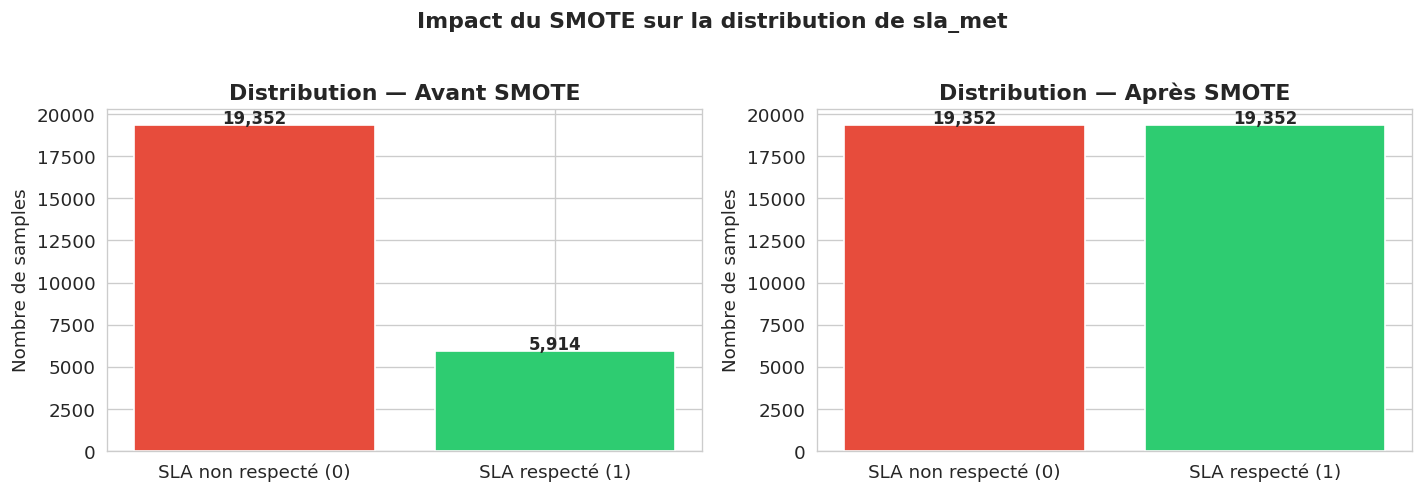

In [14]:
# ============================================================
# 7.3 — Gestion du déséquilibre de classes : SMOTE
# ============================================================
# sla_met = 0 : 76.6%  /  sla_met = 1 : 23.4%
# SMOTE génère des samples synthétiques de la classe minoritaire
# sur le train set UNIQUEMENT — jamais sur le test.

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'Avant SMOTE — Train : {dict(y_train.value_counts())}')
print(f'Après SMOTE — Train : {dict(pd.Series(y_train_res).value_counts())}')

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in zip(
    axes,
    [y_train, y_train_res],
    ['Distribution — Avant SMOTE', 'Distribution — Après SMOTE']
):
    counts = pd.Series(data).value_counts().sort_index()
    bars = ax.bar(['SLA non respecté (0)', 'SLA respecté (1)'],
                  counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Nombre de samples')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f'{val:,}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Impact du SMOTE sur la distribution de sla_met', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('smote_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. Modélisation

In [15]:
# ============================================================
# 8.1 — Fonction d'évaluation commune
# ============================================================

def evaluate_model(model, X_test, y_test, model_name):
    """
    Évalue un modèle de classification binaire probabiliste.
    Retourne un dictionnaire de métriques.
    """
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'model'    : model_name,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'roc_auc'  : roc_auc_score(y_test, y_pred_prob),
    }

    print(f'\n{"=" * 55}')
    print(f'  {model_name}')
    print(f'{"=" * 55}')
    for k, v in metrics.items():
        if k != 'model':
            print(f'  {k:<12} : {v:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["SLA non respecté", "SLA respecté"])}')

    return metrics, y_pred, y_pred_prob

results = []
print('✅ Fonction d\'évaluation prête.')

✅ Fonction d'évaluation prête.


In [16]:
# ============================================================
# 8.2 — Modèle Baseline : Régression Logistique
# ============================================================

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
lr.fit(X_train_res, y_train_res)

lr_metrics, lr_pred, lr_prob = evaluate_model(
    lr, X_test_scaled, y_test, 'Logistic Regression (Baseline)'
)
results.append(lr_metrics)


  Logistic Regression (Baseline)
  accuracy     : 0.9381
  precision    : 1.0000
  recall       : 0.7355
  f1           : 0.8476
  roc_auc      : 0.9268

                  precision    recall  f1-score   support

SLA non respecté       0.93      1.00      0.96      4839
    SLA respecté       1.00      0.74      0.85      1478

        accuracy                           0.94      6317
       macro avg       0.96      0.87      0.90      6317
    weighted avg       0.94      0.94      0.93      6317



In [17]:
# ============================================================
# 8.3 — Random Forest
# ============================================================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

rf_metrics, rf_pred, rf_prob = evaluate_model(
    rf, X_test_scaled, y_test, 'Random Forest'
)
results.append(rf_metrics)


  Random Forest
  accuracy     : 0.9425
  precision    : 0.8028
  recall       : 1.0000
  f1           : 0.8906
  roc_auc      : 0.9901

                  precision    recall  f1-score   support

SLA non respecté       1.00      0.92      0.96      4839
    SLA respecté       0.80      1.00      0.89      1478

        accuracy                           0.94      6317
       macro avg       0.90      0.96      0.93      6317
    weighted avg       0.95      0.94      0.94      6317



In [18]:
# ============================================================
# 8.4 — XGBoost
# ============================================================

# scale_pos_weight compense le déséquilibre résiduel
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train_res, y_train_res)

xgb_metrics, xgb_pred, xgb_prob = evaluate_model(
    xgb, X_test_scaled, y_test, 'XGBoost'
)
results.append(xgb_metrics)


  XGBoost
  accuracy     : 0.9425
  precision    : 0.8028
  recall       : 1.0000
  f1           : 0.8906
  roc_auc      : 0.9901

                  precision    recall  f1-score   support

SLA non respecté       1.00      0.92      0.96      4839
    SLA respecté       0.80      1.00      0.89      1478

        accuracy                           0.94      6317
       macro avg       0.90      0.96      0.93      6317
    weighted avg       0.95      0.94      0.94      6317



---
## 9. Évaluation & Comparaison des Modèles

In [20]:
# ============================================================
# 9.1 — Tableau comparatif
# ============================================================

results_df = pd.DataFrame(results).set_index('model')

print('\n📊 Comparaison des modèles :')
print(results_df.round(4).to_string())

best_model_name = results_df['roc_auc'].idxmax()
print(f'\n🏆 Meilleur modèle (ROC-AUC) : {best_model_name}')


📊 Comparaison des modèles :
                                accuracy  precision  recall      f1  roc_auc
model                                                                       
Logistic Regression (Baseline)    0.9381     1.0000  0.7355  0.8476   0.9268
Random Forest                     0.9425     0.8028  1.0000  0.8906   0.9901
XGBoost                           0.9425     0.8028  1.0000  0.8906   0.9901

🏆 Meilleur modèle (ROC-AUC) : Random Forest


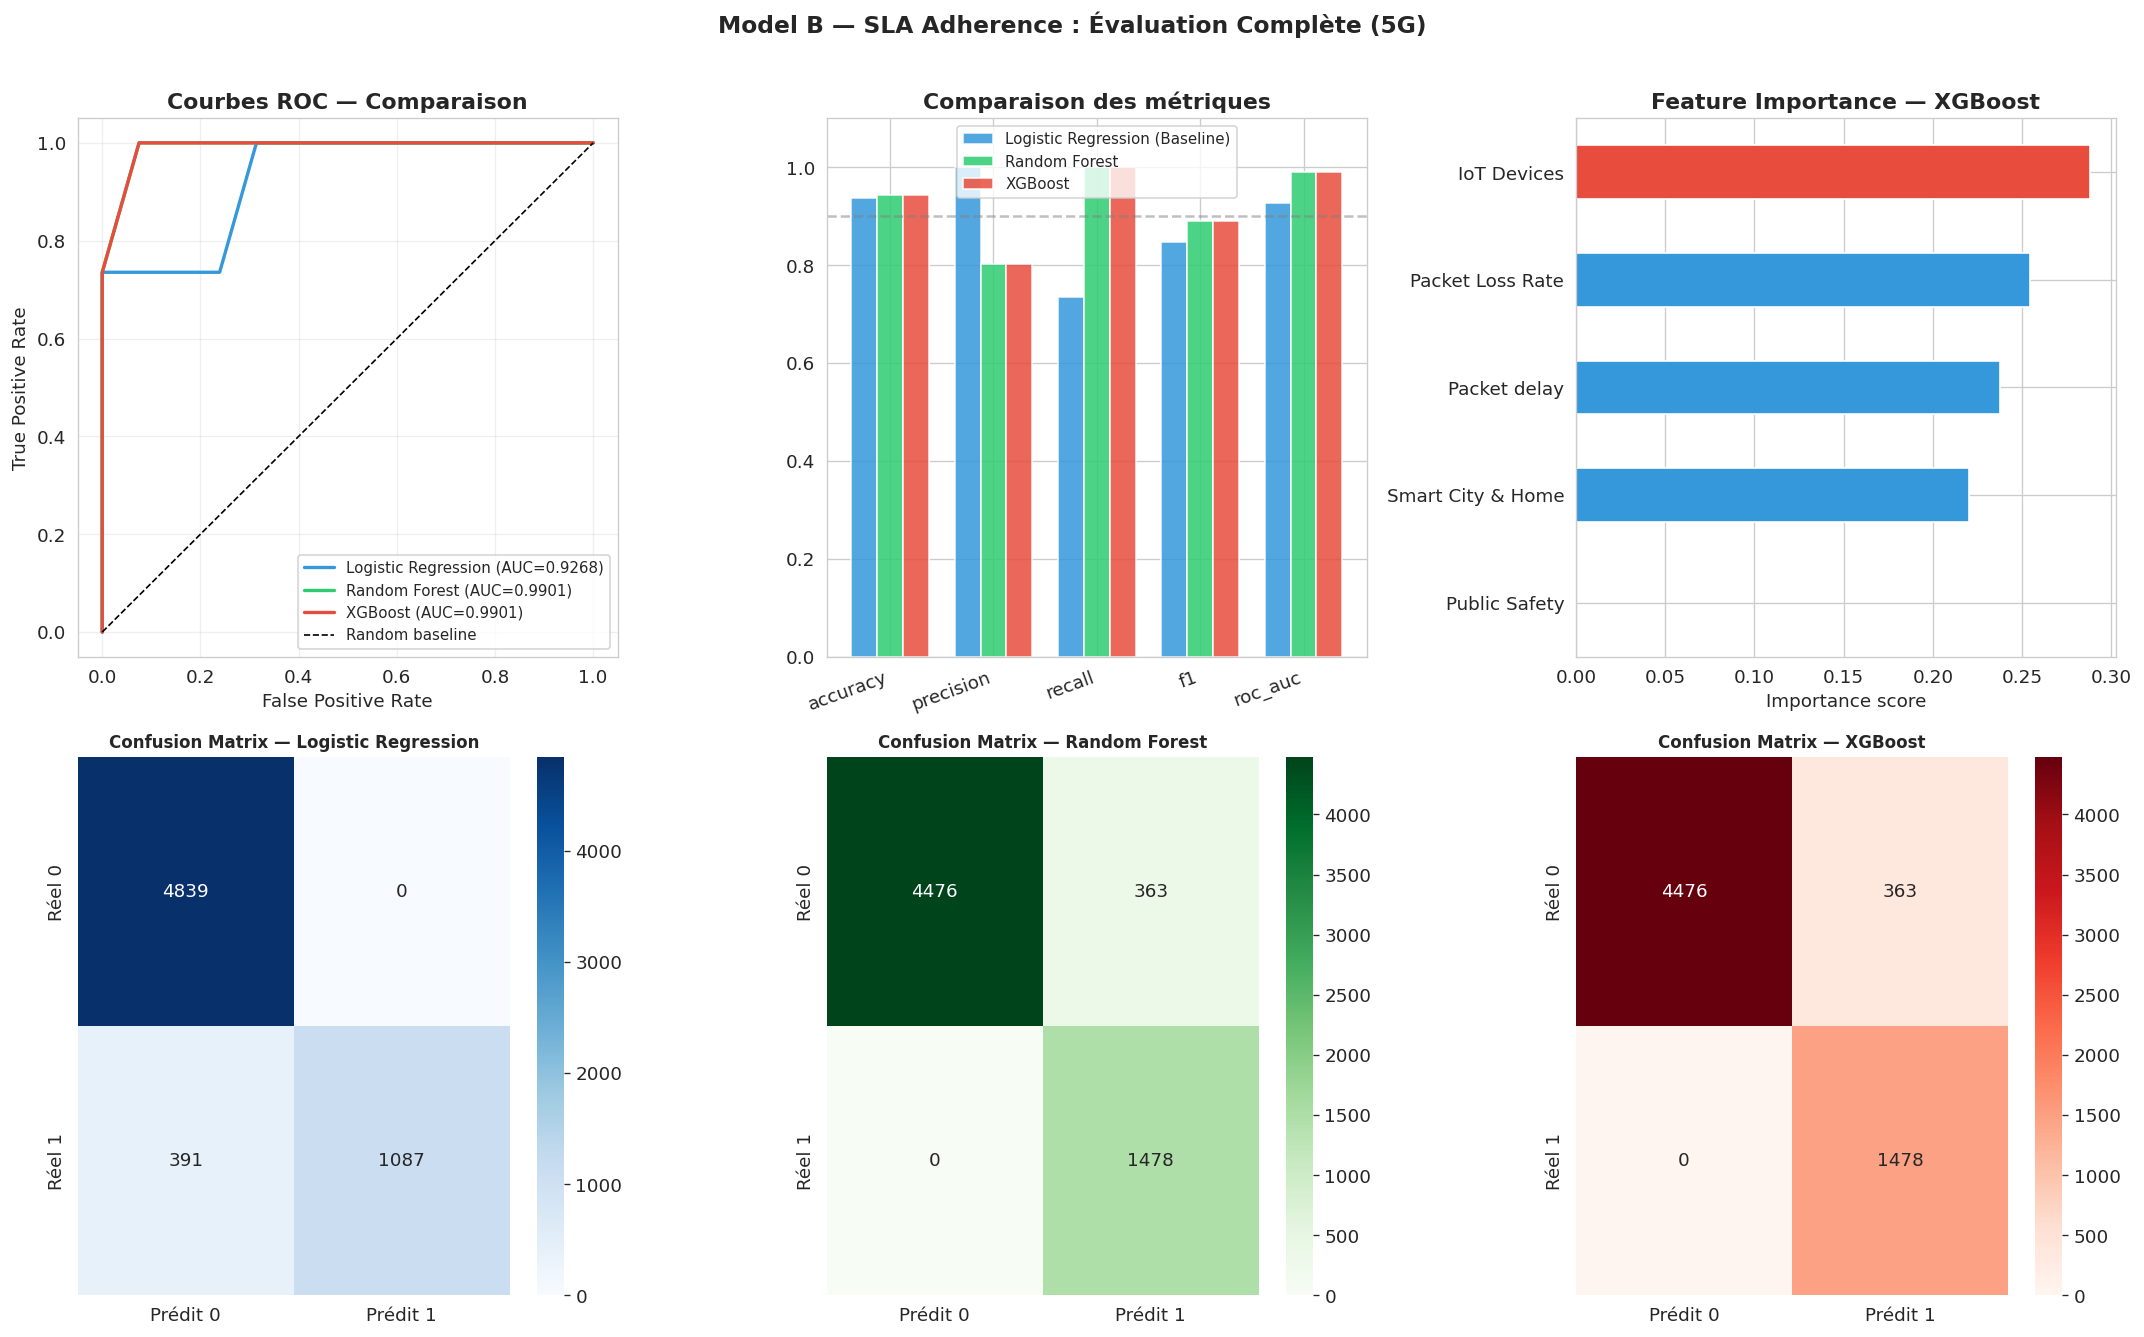

In [21]:
# ============================================================
# 9.2 — Visualisations d'évaluation complètes
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ---- Courbes ROC ----
ax_roc = axes[0, 0]
for model_name, y_prob, color in [
    ('Logistic Regression', lr_prob,  '#3498db'),
    ('Random Forest',       rf_prob,  '#2ecc71'),
    ('XGBoost',             xgb_prob, '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax_roc.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC={auc:.4f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Courbes ROC — Comparaison', fontweight='bold')
ax_roc.legend(fontsize=9)
ax_roc.grid(True, alpha=0.3)

# ---- Barplot métriques ----
ax_bar = axes[0, 1]
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x     = np.arange(len(metrics_to_plot))
width = 0.25
for i, (model_name, color) in enumerate(zip(
    results_df.index, ['#3498db', '#2ecc71', '#e74c3c']
)):
    vals = [results_df.loc[model_name, m] for m in metrics_to_plot]
    ax_bar.bar(x + i * width, vals, width, label=model_name, color=color, alpha=0.85)

ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(metrics_to_plot, rotation=20, ha='right')
ax_bar.set_ylim(0, 1.1)
ax_bar.set_title('Comparaison des métriques', fontweight='bold')
ax_bar.legend(fontsize=9)
ax_bar.axhline(0.9, color='gray', linestyle='--', alpha=0.5)

# ---- Confusion Matrices ----
for ax, y_pred, title, cmap in [
    (axes[1, 0], lr_pred,  'Logistic Regression', 'Blues'),
    (axes[1, 1], rf_pred,  'Random Forest',       'Greens'),
    (axes[1, 2], xgb_pred, 'XGBoost',             'Reds'),
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Prédit 0', 'Prédit 1'],
                yticklabels=['Réel 0', 'Réel 1'])
    ax.set_title(f'Confusion Matrix — {title}', fontweight='bold', fontsize=10)

# ---- Feature Importance XGBoost ----
ax_imp = axes[0, 2]
feat_imp = pd.Series(xgb.feature_importances_, index=FINAL_FEATURES).sort_values()
colors_imp = ['#e74c3c' if v == feat_imp.max() else '#3498db' for v in feat_imp.values]
feat_imp.plot.barh(ax=ax_imp, color=colors_imp, edgecolor='white')
ax_imp.set_title('Feature Importance — XGBoost', fontweight='bold')
ax_imp.set_xlabel('Importance score')

plt.suptitle('Model B — SLA Adherence : Évaluation Complète (5G)',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 10. Explainability — SHAP

> *DSO 5 du rapport : "Model Interpretability and Explainable AI (XAI)"*  
> SHAP fournit pour chaque prédiction **quels facteurs** ont poussé le modèle vers `sla_met=1` ou `sla_met=0`, ce qui permet l'audit SLA et justifie les actions correctives auprès de l'opérateur.

⏳ Calcul des valeurs SHAP...


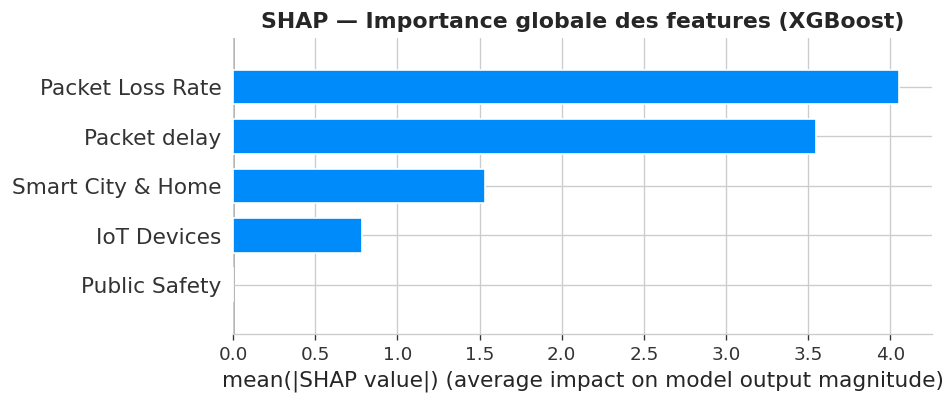

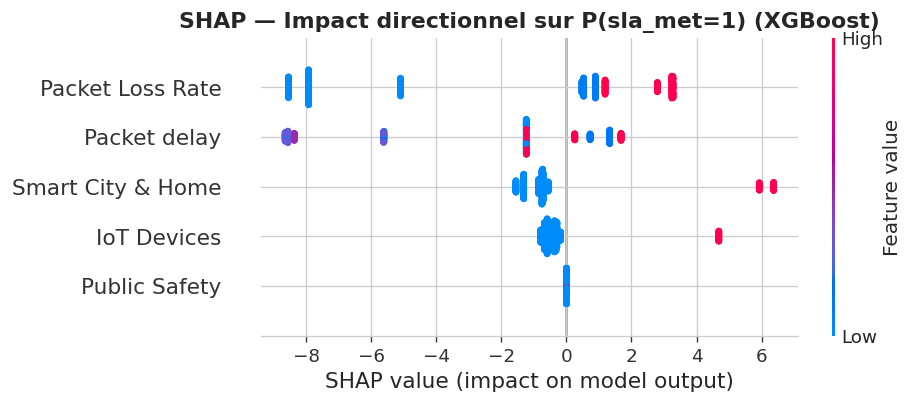


✅ Lecture des plots SHAP :
  → Rouge = valeur élevée de la feature
  → Bleu  = valeur faible de la feature
  → Position droite = contribution positive vers sla_met=1 (SLA respecté)
  → Position gauche = contribution positive vers sla_met=0 (SLA violé)


In [22]:
# ============================================================
# 10. SHAP — Explainability du meilleur modèle (XGBoost)
# ============================================================

print('⏳ Calcul des valeurs SHAP...')

X_shap_sample = X_test_scaled.sample(
    n=min(500, len(X_test_scaled)), random_state=RANDOM_STATE
)

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_shap_sample)

# --- Plot 1 : Importance globale (bar) ---
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_shap_sample,
                  feature_names=FINAL_FEATURES,
                  plot_type='bar', show=False)
plt.title('SHAP — Importance globale des features (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Plot 2 : Beeswarm (impact directionnel) ---
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X_shap_sample,
                  feature_names=FINAL_FEATURES, show=False)
plt.title('SHAP — Impact directionnel sur P(sla_met=1) (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n✅ Lecture des plots SHAP :')
print('  → Rouge = valeur élevée de la feature')
print('  → Bleu  = valeur faible de la feature')
print('  → Position droite = contribution positive vers sla_met=1 (SLA respecté)')
print('  → Position gauche = contribution positive vers sla_met=0 (SLA violé)')

---
## 11. MLOps — Sauvegarde & Déploiement

In [23]:
# ============================================================
# 11.1 — Sauvegarde du modèle, scaler et metadata
# ============================================================

os.makedirs('model_artifacts', exist_ok=True)

joblib.dump(xgb,    'model_artifacts/model_b_sla_5g_xgboost.pkl')
joblib.dump(scaler, 'model_artifacts/scaler_sla_5g.pkl')

metadata = {
    'project'             : 'Smart Slice Selection in 5G/6G',
    'groupe'              : 'Azerty67',
    'model_id'            : 'Model B — SLA Adherence',
    'network'             : '5G',
    'algorithm'           : 'XGBoost',
    'problem_type'        : 'Binary Classification — Probabilistic output',
    'deployment_location' : 'Near-RT RIC (xApp — O-RAN)',
    'output_interpretation': 'P(sla_met=1) = confidence score / risk score',
    'target'              : 'sla_met',
    'features'            : FINAL_FEATURES,
    'feature_groups'      : {
        'Core QoS'        : ['Packet Loss Rate', 'Packet delay'],
        'Contexte réseau' : ['slice Type', 'service_intensity', 'LTE/5G'],
        'Use-case'        : ['Smart City & Home', 'IoT Devices', 'Public Safety'],
    },
    'dropped_features'    : DROPPED_FEATURES,
    'preprocessing'       : {'scaler': 'StandardScaler', 'imbalance': 'SMOTE (train only)'},
    'train_samples_after_smote': int(X_train_res.shape[0]),
    'test_samples'        : int(X_test_scaled.shape[0]),
    'metrics_test_set'    : {
        'accuracy' : round(xgb_metrics['accuracy'],  4),
        'precision': round(xgb_metrics['precision'], 4),
        'recall'   : round(xgb_metrics['recall'],    4),
        'f1'       : round(xgb_metrics['f1'],        4),
        'roc_auc'  : round(xgb_metrics['roc_auc'],  4),
    },
    'random_state'        : RANDOM_STATE,
    'timestamp'           : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
}

with open('model_artifacts/metadata_model_b.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print('✅ Artifacts sauvegardés dans model_artifacts/ :')
for fname in os.listdir('model_artifacts'):
    size = os.path.getsize(f'model_artifacts/{fname}')
    print(f'   📦 {fname} ({size/1024:.1f} KB)')

✅ Artifacts sauvegardés dans model_artifacts/ :
   📦 scaler_sla_5g.pkl (1.0 KB)
   📦 model_b_sla_5g_xgboost.pkl (269.7 KB)
   📦 metadata_model_b.json (1.7 KB)


In [24]:
# ============================================================
# 11.2 — Fonction de prédiction prête pour le déploiement
# ============================================================
# Simule exactement ce que fera le xApp au Near-RT RIC
# lors de la réception d'un event E2 depuis le RAN.

def predict_sla_adherence(input_data: dict) -> dict:
    """
    Prédit P(sla_met=1) pour une session réseau active.

    Paramètres — features disponibles au Near-RT RIC :
    --------------------------------------------------
    'Packet Loss Rate'   : float — taux de perte mesuré via E2 (ex: 0.001)
    'Packet delay'       : int   — délai mesuré en ms via E2 (ex: 50)
    'slice Type'         : int   — 1=eMBB, 2=mMTC, 3=URLLC
    'service_intensity'  : int   — nb de services actifs (0, 1, 2...)
    'LTE/5G'             : int   — 1=réseau LTE/5G, 0=réseau IoT
    'Smart City & Home'  : int   — 1 si service Smart City
    'IoT Devices'        : int   — 1 si device IoT
    'Public Safety'      : int   — 1 si service Public Safety

    Retourne :
    ----------
    dict :
        'sla_prediction'     : 0 ou 1
        'sla_probability'    : float — P(sla_met=1) = confidence score
        'risk_level'         : 'LOW' / 'MEDIUM' / 'HIGH'
        'recommended_action' : str
    """
    model_  = joblib.load('model_artifacts/model_b_sla_5g_xgboost.pkl')
    scaler_ = joblib.load('model_artifacts/scaler_sla_5g.pkl')

    input_df     = pd.DataFrame([input_data])[FINAL_FEATURES]
    input_scaled = scaler_.transform(input_df)

    pred = int(model_.predict(input_scaled)[0])
    prob = float(model_.predict_proba(input_scaled)[0][1])

    if prob >= 0.70:
        risk   = 'LOW'
        action = 'Maintenir la session sur la slice assignée.'
    elif prob >= 0.40:
        risk   = 'MEDIUM'
        action = 'Surveiller — Prévoir une politique de fallback ou scaling préventif.'
    else:
        risk   = 'HIGH'
        action = 'ALERTE — Réassigner la session ou déclencher un scaling immédiat via A1 policy.'

    return {
        'sla_prediction'    : pred,
        'sla_probability'   : round(prob, 4),
        'risk_level'        : risk,
        'recommended_action': action,
    }


# ---- Tests ----
print('🔮 Test de la fonction de prédiction xApp :\n')

test_sessions = [
    {
        'label': 'Session mMTC — Smart City (SLA probablement respecté)',
        'data': {
            'Packet Loss Rate': 0.000001, 'Packet delay': 50,
            'slice Type': 2, 'service_intensity': 2, 'LTE/5G': 0,
            'Smart City & Home': 1, 'IoT Devices': 1, 'Public Safety': 0
        }
    },
    {
        'label': 'Session URLLC — Public Safety (SLA probablement violé)',
        'data': {
            'Packet Loss Rate': 0.005, 'Packet delay': 100,
            'slice Type': 3, 'service_intensity': 1, 'LTE/5G': 1,
            'Smart City & Home': 0, 'IoT Devices': 0, 'Public Safety': 1
        }
    },
    {
        'label': 'Session eMBB — Smartphone (risque intermédiaire)',
        'data': {
            'Packet Loss Rate': 0.005, 'Packet delay': 8,
            'slice Type': 1, 'service_intensity': 1, 'LTE/5G': 1,
            'Smart City & Home': 0, 'IoT Devices': 0, 'Public Safety': 0
        }
    },
]

for sess in test_sessions:
    result = predict_sla_adherence(sess['data'])
    print(f"--- {sess['label']} ---")
    print(f"  slice Type       : {sess['data']['slice Type']} "
          f"({['eMBB','mMTC','URLLC'][sess['data']['slice Type']-1]})")
    print(f"  Packet delay     : {sess['data']['Packet delay']} ms")
    print(f"  Packet Loss Rate : {sess['data']['Packet Loss Rate']}")
    for k, v in result.items():
        print(f'  {k:<22} : {v}')
    print()

🔮 Test de la fonction de prédiction xApp :

--- Session mMTC — Smart City (SLA probablement respecté) ---
  slice Type       : 2 (mMTC)
  Packet delay     : 50 ms
  Packet Loss Rate : 1e-06
  sla_prediction         : 0
  sla_probability        : 0.0573
  risk_level             : HIGH
  recommended_action     : ALERTE — Réassigner la session ou déclencher un scaling immédiat via A1 policy.

--- Session URLLC — Public Safety (SLA probablement violé) ---
  slice Type       : 3 (URLLC)
  Packet delay     : 100 ms
  Packet Loss Rate : 0.005
  sla_prediction         : 0
  sla_probability        : 0.0002
  risk_level             : HIGH
  recommended_action     : ALERTE — Réassigner la session ou déclencher un scaling immédiat via A1 policy.

--- Session eMBB — Smartphone (risque intermédiaire) ---
  slice Type       : 1 (eMBB)
  Packet delay     : 8 ms
  Packet Loss Rate : 0.005
  sla_prediction         : 0
  sla_probability        : 0.4506
  risk_level             : MEDIUM
  recommended_acti

In [25]:
# ============================================================
# 11.3 — Résumé final MLOps
# ============================================================

print('=' * 65)
print('  RÉSUMÉ FINAL — Model B / SLA Adherence / 5G')
print('=' * 65)
print(f'  Modèle               : XGBoost')
print(f'  Type                 : Classification binaire probabiliste')
print(f'  Output               : P(sla_met=1) → confidence / risk score')
print(f'  Emplacement déploiement : Near-RT RIC (xApp — O-RAN)')
print()
print(f'  Features retenues    : {len(FINAL_FEATURES)}')
print(f'    Core QoS           : Packet Loss Rate, Packet delay')
print(f'    Contexte réseau    : slice Type, service_intensity, LTE/5G')
print(f'    Use-cases          : Smart City & Home, IoT Devices, Public Safety')
print()
print(f'  Preprocessing        : StandardScaler + SMOTE (train only)')
print()
print('  Métriques test set :')
for k, v in xgb_metrics.items():
    if k != 'model':
        print(f'    {k:<12} : {v:.4f}')
print()
print('  Artifacts sauvegardés :')
print('    📦 model_artifacts/model_b_sla_5g_xgboost.pkl')
print('    📦 model_artifacts/scaler_sla_5g.pkl')
print('    📋 model_artifacts/metadata_model_b.json')
print()
print('  Prochaine étape : Model B — SLA Adherence / 6G dataset')
print('=' * 65)

  RÉSUMÉ FINAL — Model B / SLA Adherence / 5G
  Modèle               : XGBoost
  Type                 : Classification binaire probabiliste
  Output               : P(sla_met=1) → confidence / risk score
  Emplacement déploiement : Near-RT RIC (xApp — O-RAN)

  Features retenues    : 5
    Core QoS           : Packet Loss Rate, Packet delay
    Contexte réseau    : slice Type, service_intensity, LTE/5G
    Use-cases          : Smart City & Home, IoT Devices, Public Safety

  Preprocessing        : StandardScaler + SMOTE (train only)

  Métriques test set :
    accuracy     : 0.9425
    precision    : 0.8028
    recall       : 1.0000
    f1           : 0.8906
    roc_auc      : 0.9901

  Artifacts sauvegardés :
    📦 model_artifacts/model_b_sla_5g_xgboost.pkl
    📦 model_artifacts/scaler_sla_5g.pkl
    📋 model_artifacts/metadata_model_b.json

  Prochaine étape : Model B — SLA Adherence / 6G dataset
